Pinging 10.2.0.84 for 1 seconds...
[0.0s] 7.67 ms


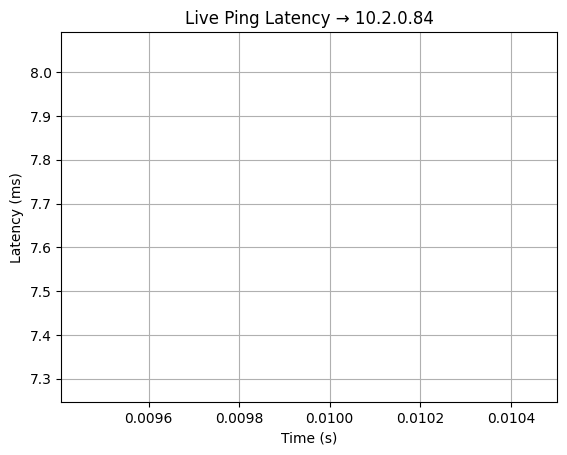

[0.1s] 2.67 ms
[0.2s] 5.76 ms
[0.2s] 3.90 ms
[0.2s] 5.58 ms
[0.2s] 12.94 ms
[0.3s] 0.00 ms
[0.3s] 24.65 ms
[0.3s] 4.15 ms
[0.4s] 10.07 ms
[0.4s] 0.00 ms
[0.4s] 18.55 ms
[0.5s] 3.93 ms
[0.5s] 14.52 ms
[0.5s] 2.19 ms
[0.6s] 19.44 ms
[0.6s] 2.60 ms
[0.6s] 14.53 ms
[0.6s] 3.74 ms
[0.7s] 7.65 ms
[0.7s] 4.33 ms
[0.8s] 103.51 ms
[0.9s] 26.46 ms
[1.0s] 157.21 ms


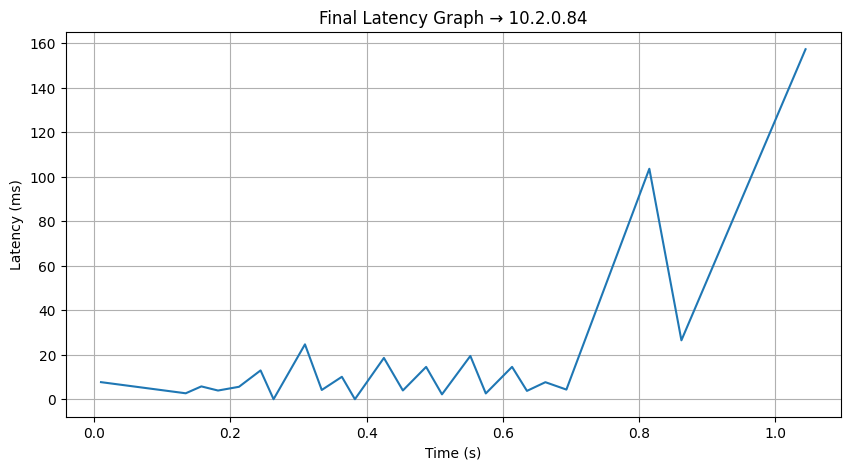

Done.


In [ ]:
import time
import matplotlib.pyplot as plt
from ping3 import ping

TARGET = "10.2.0.84"
INTERVAL = 0.001
WINDOW = 100
SEC_LIMIT = 1  # <-- RUN TIME LIMIT (seconds) 

times = []
latencies = []

plt.ion()
fig, ax = plt.subplots()

start_time = time.time()

print(f"Pinging {TARGET} for {SEC_LIMIT} seconds...")

while True:

    now_total = time.time() - start_time
    if now_total >= SEC_LIMIT:
        break

    delay = ping(TARGET, timeout=2)

    now = time.time() - start_time

    if delay is None:
        latency_ms = None
        print(f"[{now:.1f}s] Timeout")
    else:
        latency_ms = delay * 1000
        print(f"[{now:.1f}s] {latency_ms:.2f} ms")

    times.append(now)
    latencies.append(latency_ms if latency_ms is not None else 0)

    # Sliding window
    if len(times) > WINDOW:
        times.pop(0)
        latencies.pop(0)

    # Live plot
    ax.clear()
    ax.plot(times, latencies)
    ax.set_title(f"Live Ping Latency → {TARGET}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Latency (ms)")
    ax.grid()

    plt.pause(0.01)

    time.sleep(INTERVAL)

# ===== FINAL GRAPH =====

plt.ioff()

plt.figure(figsize=(10,5))
plt.plot(times, latencies)
plt.title(f"Final Latency Graph → {TARGET}")
plt.xlabel("Time (s)")
plt.ylabel("Latency (ms)")
plt.grid()
plt.show()

print("Done.")
